---
## CELL 1 

In [1]:
!pip install timm scipy opencv-python-headless matplotlib -q
print("All dependencies installed.")

All dependencies installed.


---
## CELL 2 — Imports

In [2]:
import os, math, random, warnings
from pathlib import Path

import cv2
import numpy as np
import scipy.io as sio
import scipy.ndimage
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms

import timm

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Imports done.")
print(f" Device: {DEVICE}")
if DEVICE.type == 'cpu':
    print(" WARNING: No GPU detected!")

 Imports done.
 Device: cuda


---
## CELL 2 — Set Data Paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
"""
# ============================================================
# OPTION A — Dataset is in Google Drive (RECOMMENDED)
# ============================================================
# Upload your ShanghaiTech folder to:
#   MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech/
# Then run this block.

# from google.colab import drive
# drive.mount('/content/drive')

# DATA_ROOT = Path("/content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech")
# CHECKPOINT_DIR = Path("/content/drive/MyDrive/Metro-Crowd-Project/checkpoints")
# CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# OPTION B — Upload a .zip directly to Colab (no Drive needed)
# ============================================================
# Upload ShanghaiTech.zip via the Files panel (left sidebar), then uncomment:

# !unzip -q /content/ShanghaiTech.zip -d /content/
# DATA_ROOT      = Path("/content/ShanghaiTech")
# CHECKPOINT_DIR = Path("/content/checkpoints")
# CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# OPTION C — Already extracted in /content/
# ============================================================
# DATA_ROOT      = Path("/content/ShanghaiTech")
# CHECKPOINT_DIR = Path("/content/checkpoints")
# CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# OPTION D —

from google.colab import drive
from pathlib import Path

# 1. Mount the Drive
drive.mount('/content/drive')

# 2. Define your Drive Paths
# Adjust the zip name if it's "archive.zip" or "ShanghaiTech.zip"
ZIP_PATH = "/content/drive/MyDrive/Metro-Crowd-Project/datasets/archive.zip"
DEST_DIR = "/content/drive/MyDrive/Metro-Crowd-Project/datasets/"

# 3. Unzip directly into your Drive folder
# This will create /content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech/...
print("Unzipping to Drive... this may take a few minutes for ShanghaiTech.")
!unzip -q {ZIP_PATH} -d {DEST_DIR}
print("Done!")

# 4. Set your variables for the rest of your code
DATA_ROOT      = Path("/content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech")
CHECKPOINT_DIR = Path("/content/drive/MyDrive/Metro-Crowd-Project/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# VERIFY — Runs for all options
# ============================================================
assert DATA_ROOT.exists(), f" DATA_ROOT not found: {DATA_ROOT}\nCheck your path above!"
print(f" DATA_ROOT found : {DATA_ROOT}")
print(f" Checkpoints dir : {CHECKPOINT_DIR}")
"""

'\n# ============================================================\n# OPTION A — Dataset is in Google Drive (RECOMMENDED)\n# ============================================================\n# Upload your ShanghaiTech folder to:\n#   MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech/\n# Then run this block.\n\n# from google.colab import drive\n# drive.mount(\'/content/drive\')\n\n# DATA_ROOT = Path("/content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech")\n# CHECKPOINT_DIR = Path("/content/drive/MyDrive/Metro-Crowd-Project/checkpoints")\n# CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)\n\n# ============================================================\n# OPTION B — Upload a .zip directly to Colab (no Drive needed)\n# ============================================================\n# Upload ShanghaiTech.zip via the Files panel (left sidebar), then uncomment:\n\n# !unzip -q /content/ShanghaiTech.zip -d /content/\n# DATA_ROOT      = Path("/content/ShanghaiTech")\n# CHECKPOINT_DIR = Pa

---
## CELL 4 — Hyperparameters
**Edit this cell to switch between Part A / Part B or change training settings.**

In [5]:
import random
import numpy as np
import torch

# ── Paths ─────────────────────────────────────────────────────
GDRIVE_ROOT    = Path("/content/drive/MyDrive/Metro-Crowd-Project")
DATA_ROOT      = GDRIVE_ROOT / "datasets" / "ShanghaiTech"
CHECKPOINT_DIR = GDRIVE_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PART = "part_B"

# These will be overwritten by the copy cell below
# Defined here just so Cell 6 doesn't throw NameError
TRAIN_IMG_PATH = DATA_ROOT / DATASET_PART / "train_data" / "images"
TRAIN_GT_PATH  = DATA_ROOT / DATASET_PART / "train_data" / "ground-truth"
TEST_IMG_PATH  = DATA_ROOT / DATASET_PART / "test_data"  / "images"
TEST_GT_PATH   = DATA_ROOT / DATASET_PART / "test_data"  / "ground-truth"

TRAIN_CACHE = CHECKPOINT_DIR / f"train_density_cache_{DATASET_PART}.pkl"
TEST_CACHE  = CHECKPOINT_DIR / f"test_density_cache_{DATASET_PART}.pkl"
CHECKPOINT_PATH = CHECKPOINT_DIR / f"swin_crowd_{DATASET_PART}_best.pth"

# ── Model ─────────────────────────────────────────────────────
SWIN_MODEL_NAME = "swin_small_patch4_window7_224"
PRETRAINED      = True
DENSITY_SCALE   = 8
GAUSSIAN_SIGMA  = 15

# ── Training ──────────────────────────────────────────────────
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS   = 300
BATCH_SIZE   = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
LR_MIN        = 1e-6
CROP_SIZE     = 256
NUM_WORKERS   = 0
PIN_MEMORY    = False
SEED          = 42

IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Verify ────────────────────────────────────────────────────
print(f"Device        : {DEVICE}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
for name, p in [("Train Img", TRAIN_IMG_PATH), ("Train GT", TRAIN_GT_PATH),
                ("Test Img",  TEST_IMG_PATH),  ("Test GT",  TEST_GT_PATH)]:
    print(f"  {'✅' if p.exists() else '❌'} {name}: {p}")

Device        : cuda
Checkpoint dir: /content/drive/MyDrive/Metro-Crowd-Project/checkpoints
  ✅ Train Img: /content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech/part_B/train_data/images
  ✅ Train GT: /content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech/part_B/train_data/ground-truth
  ✅ Test Img: /content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech/part_B/test_data/images
  ✅ Test GT: /content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech/part_B/test_data/ground-truth


In [7]:
# NEW CELL - Copy dataset to local disk

import shutil, time

LOCAL_DATA = Path("/content/ShanghaiTech")

if LOCAL_DATA.exists():
    print(" Already exists locally — skipping copy")
else:
    print("Copying dataset from Drive to local disk...")
    start = time.time()
    shutil.copytree(str(DATA_ROOT), str(LOCAL_DATA))
    print(f" Copied in {(time.time()-start)/60:.1f} mins")

# Overwrite paths to local
TRAIN_IMG_PATH = LOCAL_DATA / DATASET_PART / "train_data" / "images"
TRAIN_GT_PATH  = LOCAL_DATA / DATASET_PART / "train_data" / "ground-truth"
TEST_IMG_PATH  = LOCAL_DATA / DATASET_PART / "test_data"  / "images"
TEST_GT_PATH   = LOCAL_DATA / DATASET_PART / "test_data"  / "ground-truth"

# Verify
for name, p in [("Train Img", TRAIN_IMG_PATH), ("Train GT", TRAIN_GT_PATH),
                ("Test Img",  TEST_IMG_PATH),  ("Test GT",  TEST_GT_PATH)]:
    files = list(p.glob("*"))
    print(f"  {'✅' if len(files) > 0 else '❌'} {name}: {len(files)} files")

Copying dataset from Drive to local disk...
 Copied in 4.0 mins
  ✅ Train Img: 400 files
  ✅ Train GT: 400 files
  ✅ Test Img: 316 files
  ✅ Test GT: 316 files


---
## CELL 5 — Ground Truth Parser & Density Map Generator

 GT parsed: GT_IMG_357.mat
   Heads: 63  |  density sum: 63.0


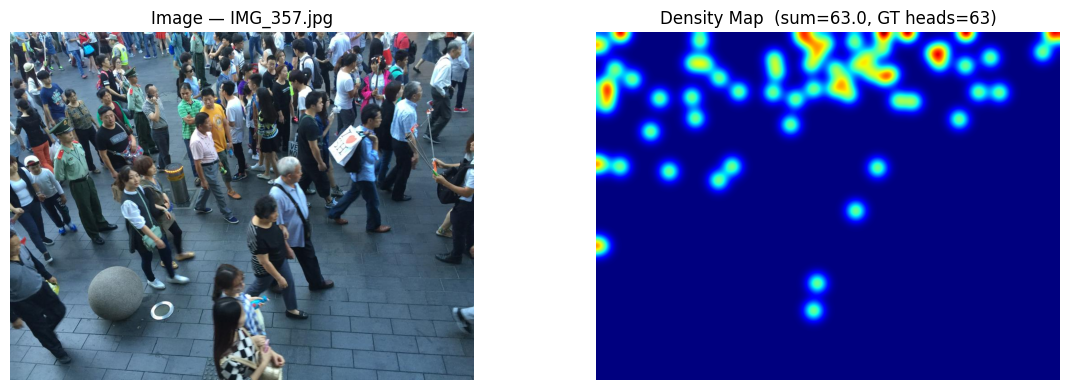

In [19]:
import scipy.io as sio
import scipy.ndimage
import cv2

def load_gt_points(mat_path):
    mat = sio.loadmat(mat_path)
    pts = mat["image_info"][0][0][0][0][0]
    return pts.astype(np.float32)

def generate_density_map(image_shape, points, sigma=GAUSSIAN_SIGMA):
    H, W    = image_shape
    density = np.zeros((H, W), dtype=np.float32)
    N       = len(points)
    if N == 0:
        return density

    # Place all points at once then single gaussian filter
    xs = np.clip(points[:, 0].astype(int), 0, W - 1)
    ys = np.clip(points[:, 1].astype(int), 0, H - 1)
    np.add.at(density, (ys, xs), 1.0)
    density = scipy.ndimage.gaussian_filter(density, sigma=sigma)
    return density

# Quick sanity check
sample_gt  = next(TRAIN_GT_PATH.glob("*.mat"))
sample_img = TRAIN_IMG_PATH / (sample_gt.stem.replace("GT_", "") + ".jpg")
pts        = load_gt_points(str(sample_gt))
img_bgr    = cv2.imread(str(sample_img))
H, W       = img_bgr.shape[:2]
dmap       = generate_density_map((H, W), pts)
print(f" GT parsed: {sample_gt.name}")
print(f"   Heads: {len(pts)}  |  density sum: {dmap.sum():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Image — {sample_img.name}")
axes[0].axis("off")
axes[1].imshow(dmap, cmap="jet")
axes[1].set_title(f"Density Map  (sum={dmap.sum():.1f}, GT heads={len(pts)})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [18]:
import os
for cache_path in [TRAIN_CACHE, TEST_CACHE]:
    if Path(cache_path).exists():
        os.remove(cache_path)
        print(f"🗑️ Deleted: {cache_path}")

In [20]:
# NEW CELL - Precompute density maps

import pickle, time

def precompute_density_maps(img_dir, gt_dir, cache_path):
    cache_path = Path(cache_path)
    if cache_path.exists():
        with open(cache_path, "rb") as f:
            existing = pickle.load(f)
        if len(existing) > 0:
            print(f" Cache exists with {len(existing)} maps — skipping")
            return
        else:
            print(f"  Cache exists but empty — regenerating")
            cache_path.unlink()

    print(f"Generating from: {img_dir}")
    cache     = {}
    img_paths = sorted(Path(img_dir).glob("*.jpg"))
    total     = len(img_paths)
    start     = time.time()

    for i, img_path in enumerate(img_paths):
        gt_path = Path(gt_dir) / f"GT_{img_path.stem}.mat"
        if not gt_path.exists():
            print(f"  Missing: {gt_path.name}")
            continue
        img     = cv2.imread(str(img_path))
        H, W    = img.shape[:2]
        points  = load_gt_points(str(gt_path))
        density = generate_density_map((H, W), points)
        cache[img_path.stem] = density
        if (i + 1) % 30 == 0:
            eta = ((time.time()-start)/(i+1)) * (total-i-1)
            print(f"  {i+1}/{total}  |  ETA: {eta:.0f}s")

    with open(cache_path, "wb") as f:
        pickle.dump(cache, f)
    print(f" Saved {len(cache)} maps → {cache_path}")

print("=== Train ===")
precompute_density_maps(TRAIN_IMG_PATH, TRAIN_GT_PATH, TRAIN_CACHE)
print("\n=== Test ===")
precompute_density_maps(TEST_IMG_PATH, TEST_GT_PATH, TEST_CACHE)

=== Train ===
Generating from: /content/ShanghaiTech/part_B/train_data/images
  30/400  |  ETA: 49s
  60/400  |  ETA: 41s
  90/400  |  ETA: 37s
  120/400  |  ETA: 34s
  150/400  |  ETA: 31s
  180/400  |  ETA: 27s
  210/400  |  ETA: 23s
  240/400  |  ETA: 20s
  270/400  |  ETA: 16s
  300/400  |  ETA: 12s
  330/400  |  ETA: 8s
  360/400  |  ETA: 5s
  390/400  |  ETA: 1s
 Saved 400 maps → /content/drive/MyDrive/Metro-Crowd-Project/checkpoints/train_density_cache_part_B.pkl

=== Test ===
Generating from: /content/ShanghaiTech/part_B/test_data/images
  30/316  |  ETA: 43s
  60/316  |  ETA: 35s
  90/316  |  ETA: 31s
  120/316  |  ETA: 29s
  150/316  |  ETA: 24s
  180/316  |  ETA: 19s
  210/316  |  ETA: 15s
  240/316  |  ETA: 11s
  270/316  |  ETA: 7s
  300/316  |  ETA: 2s
 Saved 316 maps → /content/drive/MyDrive/Metro-Crowd-Project/checkpoints/test_density_cache_part_B.pkl


---
## CELL 6 — PyTorch Dataset & DataLoaders

In [21]:
class ShanghaiTechDataset(Dataset):
    def __init__(self, img_dir, gt_dir, crop_size=None, augment=False, cache_path=None):
        self.img_dir   = Path(img_dir)
        self.gt_dir    = Path(gt_dir)
        self.crop_size = crop_size
        self.augment   = augment
        self.normalize = transforms.Normalize(mean=IMG_MEAN, std=IMG_STD)

        self.img_paths = sorted(self.img_dir.glob("*.jpg"))
        if not self.img_paths:
            self.img_paths = sorted(self.img_dir.glob("*.png"))
        assert len(self.img_paths) > 0, f"No images found in {img_dir}"

        self.cache = None
        if cache_path and Path(cache_path).exists():
            import pickle
            with open(cache_path, "rb") as f:
                self.cache = pickle.load(f)
            print(f" Loaded cache ({len(self.cache)} maps)")

    def __len__(self):
        return len(self.img_paths)

    def _get_gt_path(self, img_path):
        return self.gt_dir / f"GT_{img_path.stem}.mat"

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img      = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        H, W     = img.shape[:2]

        if self.cache is not None:
            density = self.cache[img_path.stem].copy()
        else:
            points  = load_gt_points(str(self._get_gt_path(img_path)))
            density = generate_density_map((H, W), points)

        # Simple fixed crop
        if self.crop_size:
            cs = self.crop_size
            H, W = img.shape[:2]
            if H < cs or W < cs:
                scale = cs / min(H, W)
                new_H = max(cs, int(H * scale))
                new_W = max(cs, int(W * scale))
                img     = cv2.resize(img,     (new_W, new_H))
                density = cv2.resize(density, (new_W, new_H))
                H, W    = new_H, new_W
            x1 = random.randint(0, W - cs)
            y1 = random.randint(0, H - cs)
            img     = img    [y1:y1+cs, x1:x1+cs]
            density = density[y1:y1+cs, x1:x1+cs]

        # Horizontal flip
        if self.augment and random.random() > 0.5:
            img     = np.fliplr(img    ).copy()
            density = np.fliplr(density).copy()

        # Colour augmentation
        if self.augment:
            img = img.astype(np.float32)
            img *= random.uniform(0.7, 1.3)
            mean = img.mean()
            img  = (img - mean) * random.uniform(0.8, 1.2) + mean
            img  = np.clip(img, 0, 255).astype(np.uint8)

        # Preserve count through resize
        dH = img.shape[0] // DENSITY_SCALE
        dW = img.shape[1] // DENSITY_SCALE
        density_sum_before = density.sum()
        density_small      = cv2.resize(density, (dW, dH), interpolation=cv2.INTER_LINEAR)
        if density_small.sum() > 0:
            density_small = density_small * (density_sum_before / density_small.sum())

        img_t = self.normalize(
            torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        )
        den_t = torch.from_numpy(density_small).float().unsqueeze(0)
        return img_t, den_t, str(img_path)


def build_dataloaders():
    train_ds = ShanghaiTechDataset(
        TRAIN_IMG_PATH, TRAIN_GT_PATH,
        crop_size=CROP_SIZE, augment=True,
        cache_path=TRAIN_CACHE)
    test_ds = ShanghaiTechDataset(
        TEST_IMG_PATH, TEST_GT_PATH,
        crop_size=None, augment=False,
        cache_path=TEST_CACHE)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=NUM_WORKERS,
                              pin_memory=PIN_MEMORY, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=1,
                              shuffle=False, num_workers=NUM_WORKERS,
                              pin_memory=PIN_MEMORY)
    print(f" Train: {len(train_ds)} | Test: {len(test_ds)}")
    return train_loader, test_loader

train_loader, test_loader = build_dataloaders()

imgs, densities, paths = next(iter(train_loader))
print(f"\nBatch check:")
print(f"  Image   : {imgs.shape}  dtype={imgs.dtype}")
print(f"  Density : {densities.shape}  dtype={densities.dtype}")
print(f"  Counts  : {densities.sum((1,2,3)).tolist()}")

 Loaded cache (400 maps)
 Loaded cache (316 maps)
 Train: 400 | Test: 316

Batch check:
  Image   : torch.Size([8, 3, 256, 256])  dtype=torch.float32
  Density : torch.Size([8, 1, 32, 32])  dtype=torch.float32
  Counts  : [5.538437843322754, 18.604516983032227, 5.403177261352539, 30.981801986694336, 2.11482310295105, 2.764596939086914, 4.5609636306762695, 2.394592761993408]


In [27]:
# NEW CELL - Verify everything before training

import pickle

# Check caches
for name, path in [("Train", TRAIN_CACHE), ("Test", TEST_CACHE)]:
    with open(path, "rb") as f:
        cache = pickle.load(f)
    print(f" {name} cache: {len(cache)} maps")

# Check batch
imgs, densities, paths = next(iter(train_loader))
print(f"\n Train batch: images={imgs.shape} densities={densities.shape}")
print(f"   Counts in batch: {densities.sum((1,2,3)).tolist()}")

imgs, densities, paths = next(iter(test_loader))
print(f" Test  batch: images={imgs.shape} densities={densities.shape}")

# Check GPU
print(f"\n Device: {DEVICE}")
print(f" Model on: {next(model.parameters()).device}")

 Train cache: 400 maps
 Test cache: 316 maps

 Train batch: images=torch.Size([8, 3, 256, 256]) densities=torch.Size([8, 1, 32, 32])
   Counts in batch: [11.448352813720703, 19.966806411743164, 10.96310043334961, 0.002243294380605221, 2.099092483520508, 1.9994902610778809, 6.4607977867126465, 54.48189926147461]
 Test  batch: images=torch.Size([1, 3, 768, 1024]) densities=torch.Size([1, 1, 96, 128])

 Device: cuda
 Model on: cuda:0


---
## CELL 7 — Model Definition (Backbone + FPN Decoder)

In [22]:
class SwinBackbone(nn.Module):
    STAGE_CHANNELS = {
        "swin_tiny_patch4_window7_224"  : [96,  192, 384,  768],
        "swin_small_patch4_window7_224" : [96,  192, 384,  768],
        "swin_base_patch4_window7_224"  : [128, 256, 512, 1024],
    }

    def __init__(self, model_name=SWIN_MODEL_NAME, pretrained=PRETRAINED):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=pretrained,
            features_only=True, out_indices=(0, 1, 2, 3),
            img_size=256
        )
        # Disable strict size checking
        for module in self.backbone.modules():
            if hasattr(module, 'strict_img_size'):
                module.strict_img_size = False
            if hasattr(module, 'dynamic_img_pad'):
                module.dynamic_img_pad = True

        self.out_channels = self.STAGE_CHANNELS.get(model_name, [96, 192, 384, 768])
        print(f"  Backbone      : {model_name}  (pretrained={pretrained})")
        print(f"  Stage channels: {self.out_channels}")

    def forward(self, x):
        feats = self.backbone(x)
        return [f.permute(0, 3, 1, 2).contiguous() for f in feats]


class ConvBNReLU(nn.Sequential):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__(
            nn.Conv2d(in_ch, out_ch, k, s, p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )


class FPNDecoder(nn.Module):
    def __init__(self, in_channels, fpn_channels=256):
        super().__init__()
        self.lateral = nn.ModuleList(
            [nn.Conv2d(c, fpn_channels, 1) for c in in_channels])
        self.smooth  = nn.ModuleList(
            [ConvBNReLU(fpn_channels, fpn_channels) for _ in in_channels])
        self.density_head = nn.Sequential(
            ConvBNReLU(fpn_channels, 128),
            ConvBNReLU(128, 64),
            nn.Conv2d(64, 1, kernel_size=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, features):
        f0, f1, f2, f3 = features
        p3 = self.smooth[3](self.lateral[3](f3))
        p2 = self.smooth[2](self.lateral[2](f2) + F.interpolate(p3, size=f2.shape[-2:], mode="bilinear", align_corners=False))
        p1 = self.smooth[1](self.lateral[1](f1) + F.interpolate(p2, size=f1.shape[-2:], mode="bilinear", align_corners=False))
        p0 = self.smooth[0](self.lateral[0](f0) + F.interpolate(p1, size=f0.shape[-2:], mode="bilinear", align_corners=False))
        if DENSITY_SCALE > 4:
            pool_factor = DENSITY_SCALE // 4
            p0 = F.avg_pool2d(p0, kernel_size=pool_factor, stride=pool_factor)
        return self.density_head(p0)


class SwinCrowdCounter(nn.Module):
    def __init__(self, backbone_name=SWIN_MODEL_NAME, fpn_channels=256, pretrained=PRETRAINED):
        super().__init__()
        self.backbone = SwinBackbone(backbone_name, pretrained)
        self.decoder  = FPNDecoder(self.backbone.out_channels, fpn_channels)

    def forward(self, x):
        return self.decoder(self.backbone(x))

    @staticmethod
    def count_from_density(density):
        return density.sum(dim=(1, 2, 3))


print("Building model...")
model = SwinCrowdCounter().to(DEVICE)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" Model built")
print(f" Total params    : {total_params:,}")
print(f" Trainable params: {trainable_params:,}")

with torch.no_grad():
    dummy     = torch.randn(1, 3, 256, 256).to(DEVICE)
    dummy_out = model(dummy)
    print(f"  Input  : {list(dummy.shape)}")
    print(f"  Output : {list(dummy_out.shape)}")

Building model...


model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

  Backbone      : swin_small_patch4_window7_224  (pretrained=True)
  Stage channels: [96, 192, 384, 768]
 Model built
 Total params    : 51,935,819
 Trainable params: 51,935,819
  Input  : [1, 3, 256, 256]
  Output : [1, 1, 32, 32]


---
## CELL 8 — Loss, Metrics, Optimizer

In [23]:
class CrowdLoss(nn.Module):
    def __init__(self, lambda_count=0.1):
        super().__init__()
        self.mse          = nn.MSELoss()
        self.lambda_count = lambda_count

    def forward(self, pred, gt):
        loss_mse   = self.mse(pred, gt)
        pred_cnt   = pred.sum(dim=(1,2,3))
        gt_cnt     = gt.sum(dim=(1,2,3))
        loss_count = F.l1_loss(pred_cnt, gt_cnt)
        return loss_mse + self.lambda_count * loss_count


def get_scheduler(optimizer, warmup_epochs=10, total_epochs=NUM_EPOCHS):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


criterion = CrowdLoss(lambda_count=0.1)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = get_scheduler(optimizer, warmup_epochs=10, total_epochs=NUM_EPOCHS)
print(" Loss, optimizer, warmup scheduler ready")

 Loss, optimizer, warmup scheduler ready


---
## CELL 9 — Checkpoints 

In [24]:
def save_checkpoint(epoch, best_mae):
    torch.save({
        "epoch"          : epoch,
        "model_state"    : model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_mae"       : best_mae,
    }, CHECKPOINT_PATH)
    print(f"  Checkpoint saved (epoch={epoch+1}, MAE={best_mae:.2f}) → {CHECKPOINT_PATH}")


def load_checkpoint():
    if not Path(CHECKPOINT_PATH).exists():
        print("  No checkpoint found — starting from scratch.")
        return 0, float("inf")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    print(f"  Checkpoint loaded from {CHECKPOINT_PATH}")
    print(f"  Resuming epoch {ckpt['epoch']+1}, best MAE={ckpt['best_mae']:.2f}")
    return ckpt["epoch"] + 1, ckpt["best_mae"]


print(" Checkpoint utilities ready.")

 Checkpoint utilities ready.


---
## CELL 10 — Train + Validate Loop Functions

In [25]:
def train_one_epoch(epoch):
    model.train()
    total_loss = 0.0
    for i, (imgs, densities, _) in enumerate(train_loader):
        imgs      = imgs.to(DEVICE, non_blocking=True)
        densities = densities.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        pred = model(imgs)
        if pred.shape != densities.shape:
            pred = F.interpolate(pred, size=densities.shape[-2:],
                                 mode="bilinear", align_corners=False)
        loss = criterion(pred, densities)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
        if (i + 1) % 20 == 0:
            print(f"    [Ep {epoch:03d} | batch {i+1:03d}/{len(train_loader):03d}]  loss={loss.item():.5f}")

    return total_loss / len(train_loader)

@torch.no_grad()
def validate():
    model.eval()
    mae_sum, mse_sum, n = 0.0, 0.0, 0
    for imgs, densities, _ in test_loader:
        imgs      = imgs.to(DEVICE, non_blocking=True)
        densities = densities.to(DEVICE, non_blocking=True)

        # Pad to multiple of 32 so Swin windows tile evenly
        B, C, H, W = imgs.shape
        pad_H = (32 - H % 32) % 32
        pad_W = (32 - W % 32) % 32
        if pad_H > 0 or pad_W > 0:
            imgs = F.pad(imgs, (0, pad_W, 0, pad_H), mode="reflect")

        pred = model(imgs)

        # Crop pred back to match density map size
        pred = pred[:, :, :H//DENSITY_SCALE, :W//DENSITY_SCALE]

        if pred.shape != densities.shape:
            pred = F.interpolate(pred, size=densities.shape[-2:],
                                 mode="bilinear", align_corners=False)

        pred_cnt = pred.sum(dim=(1,2,3)).cpu().numpy()
        gt_cnt   = densities.sum(dim=(1,2,3)).cpu().numpy()
        mae_sum += float(np.sum(np.abs(pred_cnt - gt_cnt)))
        mse_sum += float(np.sum((pred_cnt - gt_cnt) ** 2))
        n       += len(imgs)

    return mae_sum / n, math.sqrt(mse_sum / n)

print(" Train/validate functions defined.")

 Train/validate functions defined.


In [26]:
# Updating Validation

@torch.no_grad()
def validate():
    model.eval()
    mae_sum, mse_sum, n = 0.0, 0.0, 0

    for imgs, densities, _ in test_loader:
        # Resize to exactly 256x256 — same size model was built with
        B, C, H, W = imgs.shape
        imgs_resized = F.interpolate(imgs, size=(256, 256),
                                     mode="bilinear", align_corners=False)

        imgs_resized = imgs_resized.to(DEVICE, non_blocking=True)
        densities    = densities.to(DEVICE, non_blocking=True)

        pred = model(imgs_resized)   # (B, 1, 32, 32)

        # Compare counts only — sum over spatial dims
        pred_cnt = pred.sum(dim=(1,2,3)).cpu().numpy()
        gt_cnt   = densities.sum(dim=(1,2,3)).cpu().numpy()

        mae_sum += float(np.sum(np.abs(pred_cnt - gt_cnt)))
        mse_sum += float(np.sum((pred_cnt - gt_cnt) ** 2))
        n       += len(imgs)

    return mae_sum / n, math.sqrt(mse_sum / n)

print(" validate() updated")

 validate() updated


---
## CELL 11 —  Run Training

In [ ]:
RESUME = False  ## Set `RESUME = True` to continue from a saved checkpoint, `False` to start fresh.

start_epoch = 0
best_mae    = float("inf")
history     = {"train_loss": [], "val_mae": [], "val_rmse": []}

if RESUME and Path(CHECKPOINT_PATH).exists():
    start_epoch, best_mae = load_checkpoint()
else:
    print("Starting fresh")

print(f" Training {NUM_EPOCHS} epochs on {DEVICE}")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\n{'─'*55}")
    print(f"EPOCH {epoch+1}/{NUM_EPOCHS}  |  LR={scheduler.get_last_lr()[0]:.2e}")

    train_loss        = train_one_epoch(epoch + 1)
    val_mae, val_rmse = validate()
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_mae"   ].append(val_mae)
    history["val_rmse"  ].append(val_rmse)

    print(f"  Loss={train_loss:.5f}  MAE={val_mae:.2f}  RMSE={val_rmse:.2f}")

    if val_mae < best_mae:
        best_mae = val_mae
        save_checkpoint(epoch, best_mae)
        print(f" Best MAE={best_mae:.2f} — saved to Drive")

print(f"\n Done — Best MAE = {best_mae:.2f}")

Starting fresh
 Training 300 epochs on cuda

───────────────────────────────────────────────────────
EPOCH 1/300  |  LR=0.00e+00
    [Ep 001 | batch 020/050]  loss=15.33839
    [Ep 001 | batch 040/050]  loss=15.33968
  Loss=15.71151  MAE=105.68  RMSE=122.09
  Checkpoint saved (epoch=1, MAE=105.68) → /content/drive/MyDrive/Metro-Crowd-Project/checkpoints/swin_crowd_part_B_best.pth
 Best MAE=105.68 — saved to Drive

───────────────────────────────────────────────────────
EPOCH 2/300  |  LR=1.00e-05
    [Ep 002 | batch 020/050]  loss=11.12260
    [Ep 002 | batch 040/050]  loss=4.59539
  Loss=8.92877  MAE=91.01  RMSE=130.57
  Checkpoint saved (epoch=2, MAE=91.01) → /content/drive/MyDrive/Metro-Crowd-Project/checkpoints/swin_crowd_part_B_best.pth
 Best MAE=91.01 — saved to Drive

───────────────────────────────────────────────────────
EPOCH 3/300  |  LR=2.00e-05
    [Ep 003 | batch 020/050]  loss=0.46533
    [Ep 003 | batch 040/050]  loss=0.19323
  Loss=0.66592  MAE=110.17  RMSE=143.12

───

---
## CELL 12 — Training Curves

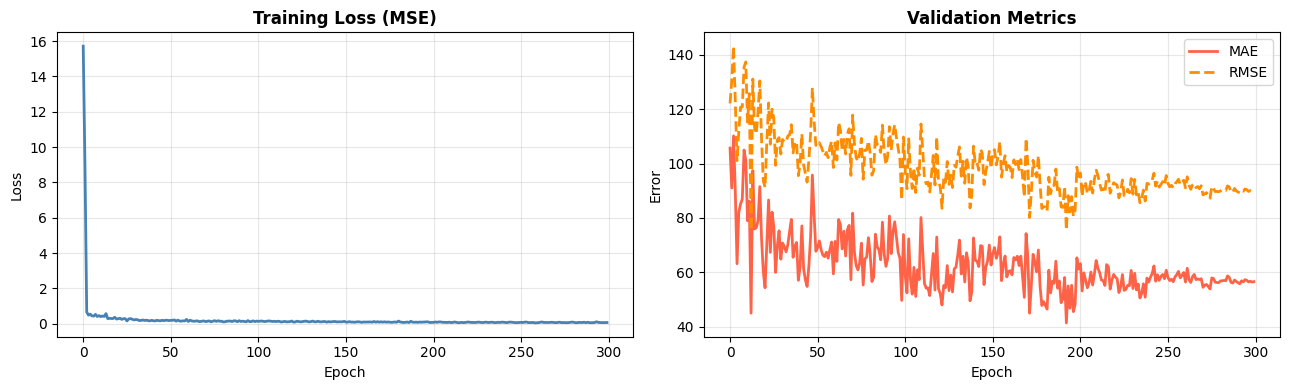

 Curves saved to Drive.


In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history["train_loss"], color="steelblue", lw=2)
ax1.set_title("Training Loss (MSE)", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(history["val_mae"],  label="MAE",  color="tomato",     lw=2)
ax2.plot(history["val_rmse"], label="RMSE", color="darkorange", lw=2, linestyle="--")
ax2.set_title("Validation Metrics", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Error")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / "training_curves.png"), dpi=150)
plt.show()
print(" Curves saved to Drive.")

---
## CELL 13 — Visualise Predictions

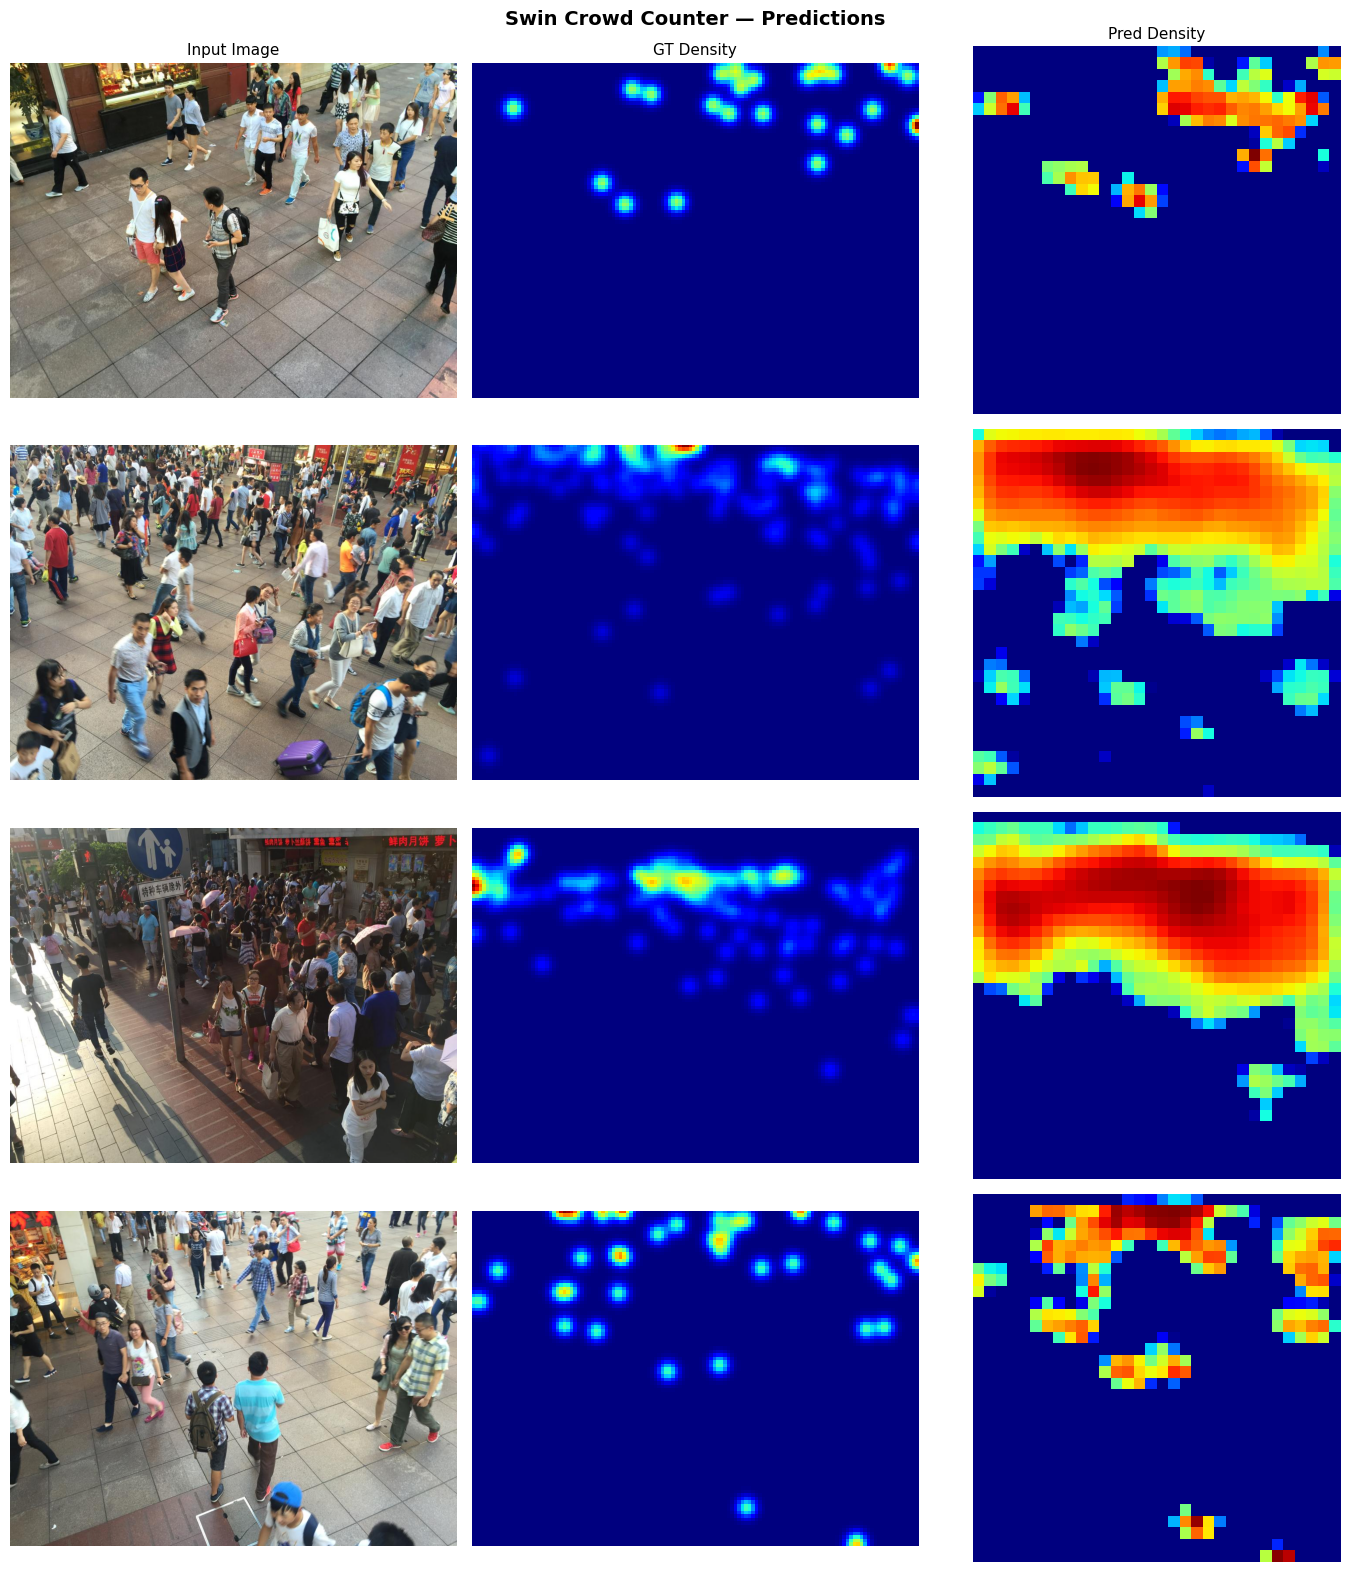

 Visualisation saved to Drive.


In [30]:
def denormalize(tensor):
    mean = torch.tensor(IMG_MEAN).view(3,1,1)
    std  = torch.tensor(IMG_STD ).view(3,1,1)
    img  = (tensor.cpu() * std + mean).clamp(0,1).numpy()
    return (img.transpose(1,2,0) * 255).astype(np.uint8)


@torch.no_grad()
def visualise_predictions(n_images=4):
    model.eval()
    fig, axes = plt.subplots(n_images, 3, figsize=(14, 4*n_images))
    fig.suptitle("Swin Crowd Counter — Predictions", fontsize=14, fontweight="bold")
    for ax, title in zip(axes[0], ["Input Image", "GT Density", "Pred Density"]):
        ax.set_title(title, fontsize=11)

    samples = 0
    for imgs, densities, paths in test_loader:
        if samples >= n_images:
            break

        # Resize to 256x256 — same as validate()
        imgs_orig = imgs.clone()
        imgs_resized = F.interpolate(imgs, size=(256, 256),
                                     mode="bilinear", align_corners=False)

        imgs_resized = imgs_resized.to(DEVICE)
        densities    = densities.to(DEVICE)

        with torch.no_grad():
            pred = model(imgs_resized)   # (B, 1, 32, 32)

        for b in range(imgs.size(0)):
            if samples >= n_images:
                break

            # Show original image (not resized) for visual clarity
            img_np  = denormalize(imgs_orig[b])
            gt_np   = densities[b, 0].cpu().numpy()
            pred_np = pred[b, 0].cpu().numpy()

            gt_count   = gt_np.sum()
            pred_count = pred_np.sum()

            axes[samples][0].imshow(img_np)
            axes[samples][0].axis("off")
            axes[samples][0].set_xlabel(Path(paths[b]).name, fontsize=8)

            axes[samples][1].imshow(gt_np, cmap="jet")
            axes[samples][1].axis("off")
            axes[samples][1].set_xlabel(f"GT: {gt_count:.1f}", fontsize=10)

            axes[samples][2].imshow(pred_np, cmap="jet")
            axes[samples][2].axis("off")
            axes[samples][2].set_xlabel(f"Pred: {pred_count:.1f}", fontsize=10)

            samples += 1

    plt.tight_layout()
    plt.savefig(str(CHECKPOINT_DIR / "predictions.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(" Visualisation saved to Drive.")


visualise_predictions(n_images=4)

---
## CELL 14 — Single Image Inference

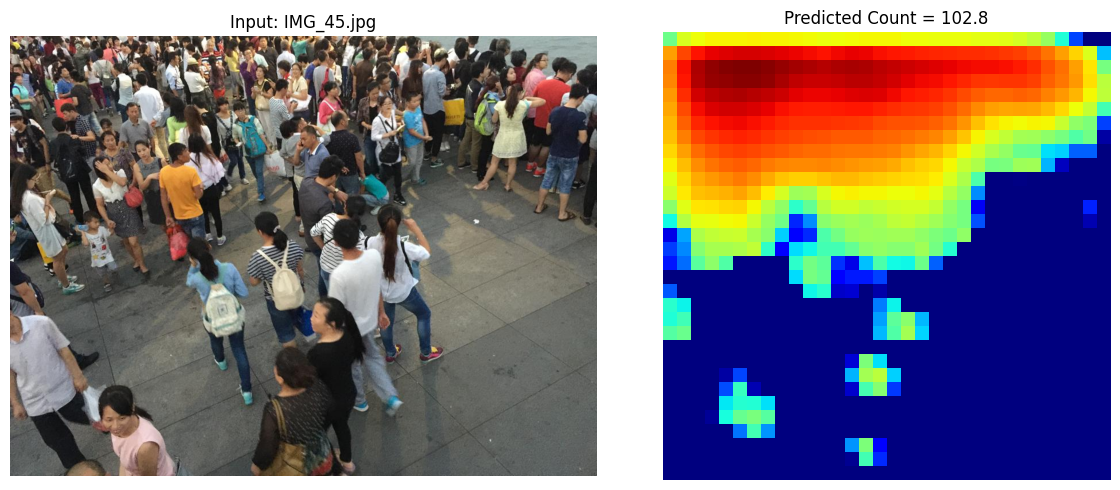

 Estimated crowd count: 102.8


In [31]:
@torch.no_grad()
def predict_single_image(image_path: str):
    model.eval()
    norm = transforms.Normalize(mean=IMG_MEAN, std=IMG_STD)

    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    # Convert to tensor and normalize
    t = norm(torch.from_numpy(img.transpose(2,0,1)).float() / 255.0)

    # Resize to 256x256 — consistent with how model was trained
    t_resized = F.interpolate(t.unsqueeze(0), size=(256, 256),
                               mode="bilinear", align_corners=False)

    density = model(t_resized.to(DEVICE))[0, 0].cpu().numpy()
    count   = float(density.sum())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img)
    axes[0].set_title(f"Input: {Path(image_path).name}")
    axes[0].axis("off")
    axes[1].imshow(density, cmap="jet")
    axes[1].set_title(f"Predicted Count = {count:.1f}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
    print(f" Estimated crowd count: {count:.1f}")
    return density, count


# Run on a random test image
sample_path = str(next(Path(TEST_IMG_PATH).glob("*.jpg")))
density_map, estimated_count = predict_single_image(sample_path)